In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv("../../data/processed/opensky/opensky_processed.csv")

print("Dataset loaded successfully.")

print(df.shape)

Dataset loaded successfully.
(7516, 16)


In [ ]:
print("OpenSky Cleaned Dataset")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

OpenSky Cleaned Dataset
Rows    : 7516
Columns : 16


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,spi,position_source
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,119.59,5.20,9829.80,3112.0,False,0
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,12.96,0.33,487.68,NaN,False,0
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,291.13,0.00,10683.24,NaN,False,0
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,165.34,0.65,670.56,NaN,False,0
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,327.49,0.00,11155.68,NaN,False,0


In [ ]:
display(df.describe())

,time_position,last_constant,longitude,latitude,baro_altitude,velocity,true_track,vertical_rate,geo_altitude,squawk,position_source
count,7.516000e+03,7.516000e+03,7516.000000,7516.000000,7516.000000,7516.000000,7516.000000,7516.000000,7516.000000,3230.000000,7516.0
mean,1.767745e+09,1.767745e+09,-44.505623,29.809020,6789.515301,156.088623,182.542976,-0.293391,6903.362115,3484.993498,0.0
std,1.705541e+02,5.981213e+01,89.415081,20.819909,4176.788758,88.899095,102.893421,4.587985,4226.026196,2147.629337,0.0
min,1.767739e+09,1.767745e+09,-175.382200,-46.844100,-68.580000,0.000000,0.000000,-25.030000,-45.720000,7.000000,0.0
25%,1.767745e+09,1.767745e+09,-101.147850,28.719825,2223.135000,67.910000,91.225000,-0.650000,2286.000000,1573.250000,0.0
50%,1.767745e+09,1.767745e+09,-83.300000,34.941100,7924.800000,183.250000,185.000000,0.000000,8042.910000,3214.000000,0.0
75%,1.767745e+09,1.767745e+09,10.230600,40.497700,10660.380000,227.780000,271.150000,0.000000,10645.140000,5338.000000,0.0
max,1.767745e+09,1.767745e+09,177.560100,69.902200,14935.200000,743.540000,359.840000,23.080000,22387.560000,7774.000000,0.0


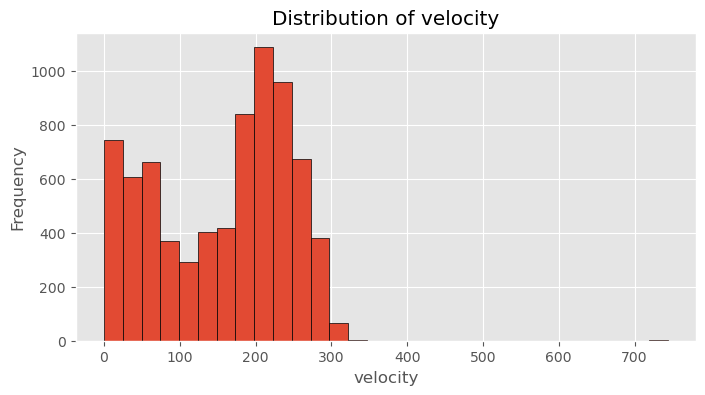

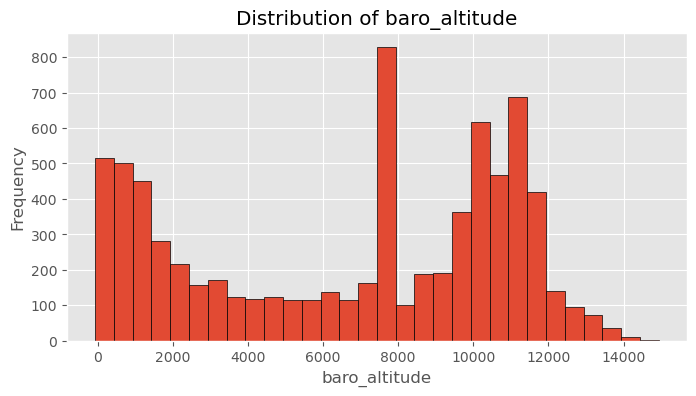

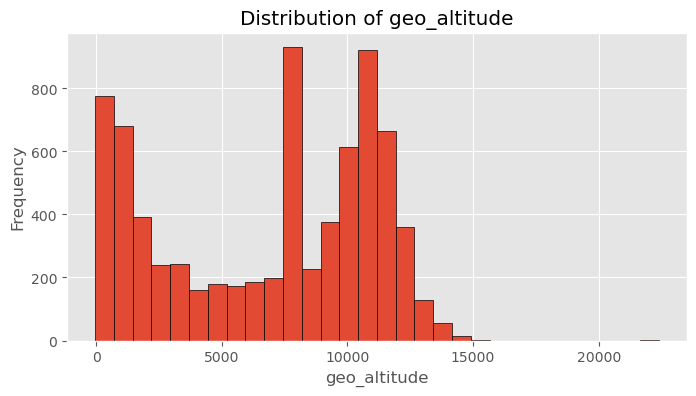

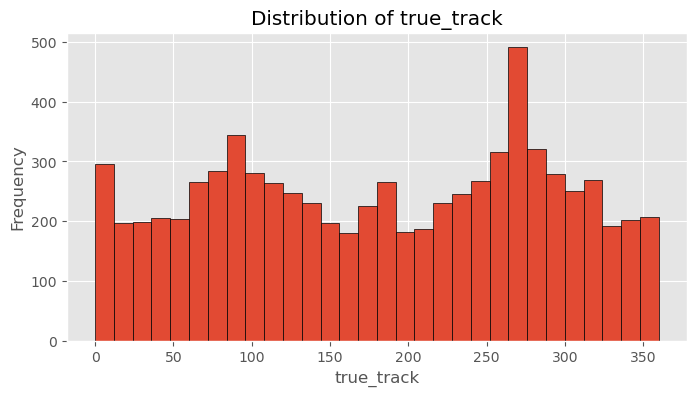

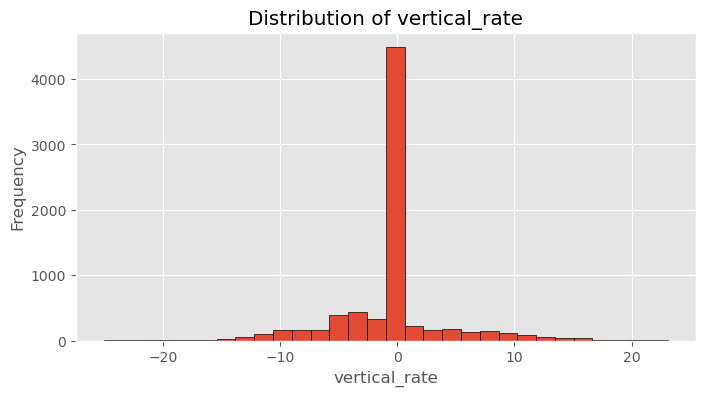

In [ ]:
numerical_columns = [
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "true_track",
    "vertical_rate"
]

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    plt.hist(
        df[column],
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

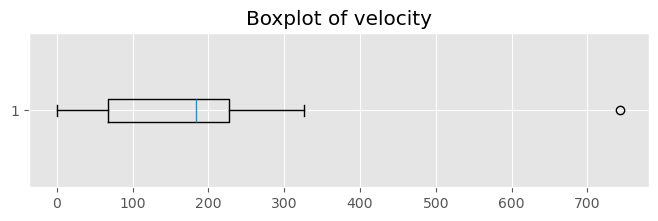

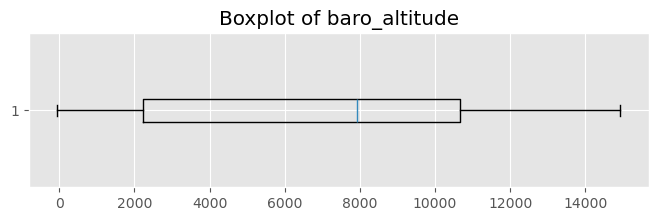

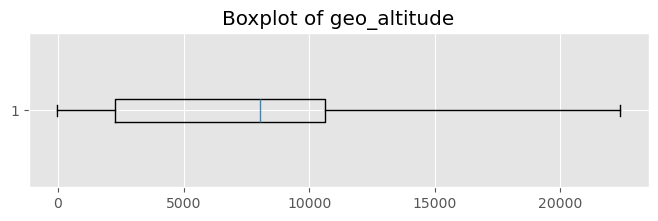

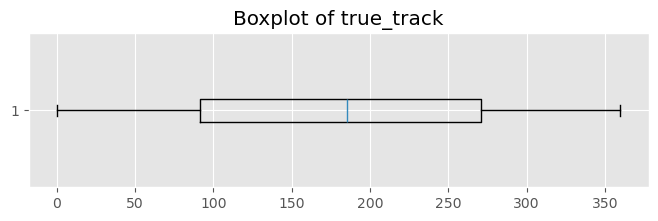

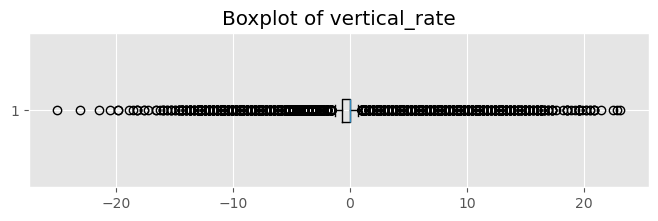

In [ ]:
for column in numerical_columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[column], vert=False)

    plt.title(f"Boxplot of {column}")

    plt.show()

## 4. Categorical Feature Analysis

This section examines the categorical variables within the OpenSky ADS-B dataset to understand the composition of aircraft observations. The analysis focuses on aircraft registration country, operational status, surveillance indicators, and position source.

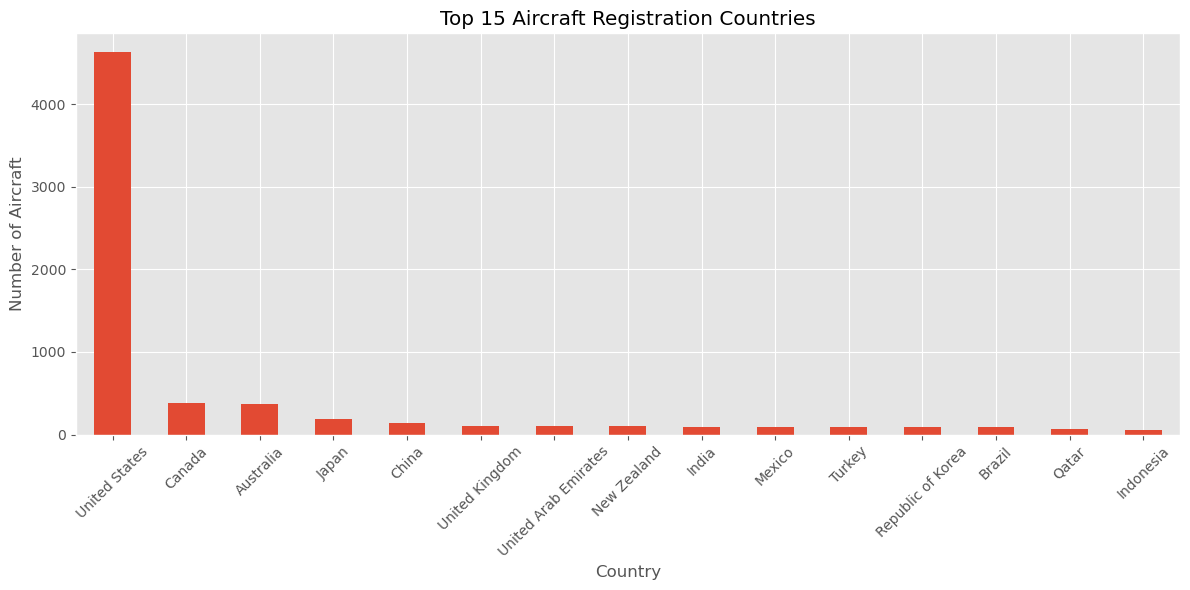

origin_country
United States           4627
Canada                   387
Australia                370
Japan                    183
China                    145
United Kingdom           101
United Arab Emirates     100
New Zealand               99
India                     96
Mexico                    93
Turkey                    93
Republic of Korea         90
Brazil                    87
Qatar                     62
Indonesia                 61
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

top_countries = df["origin_country"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_countries.plot(kind="bar")

plt.title("Top 15 Aircraft Registration Countries")

plt.xlabel("Country")

plt.ylabel("Number of Aircraft")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

display(top_countries)

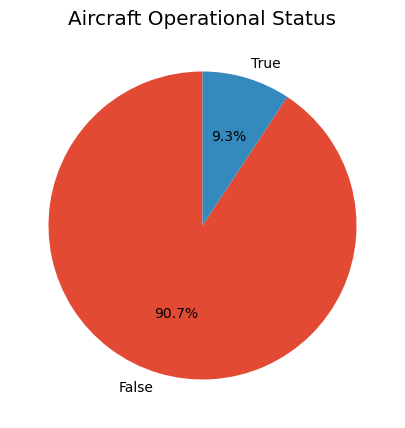

on_ground
False    6819
True      697
Name: count, dtype: int64

In [ ]:
ground_counts = df["on_ground"].value_counts()

plt.figure(figsize=(6,5))

ground_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Aircraft Operational Status")

plt.show()

display(ground_counts)

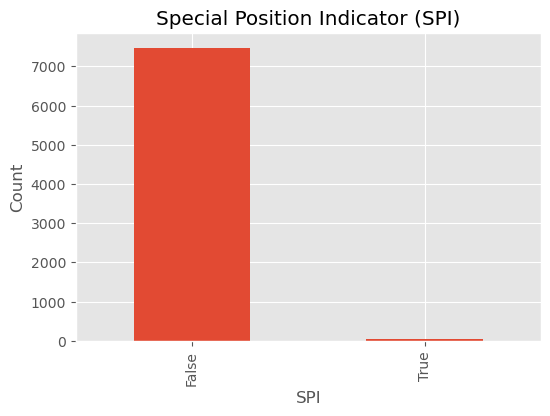

spi
False    7479
True       37
Name: count, dtype: int64

In [ ]:
spi_counts = df["spi"].value_counts()

plt.figure(figsize=(6,4))

spi_counts.plot(kind="bar")

plt.title("Special Position Indicator (SPI)")

plt.xlabel("SPI")

plt.ylabel("Count")

plt.show()

display(spi_counts)

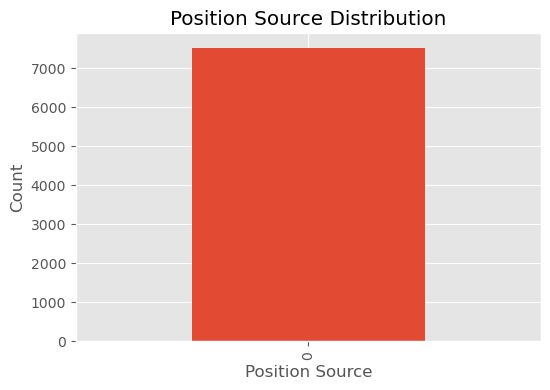

position_source
0    7516
Name: count, dtype: int64

In [ ]:
position_counts = df["position_source"].value_counts()

plt.figure(figsize=(6,4))

position_counts.plot(kind="bar")

plt.title("Position Source Distribution")

plt.xlabel("Position Source")

plt.ylabel("Count")

plt.show()

display(position_counts)

## 5. Correlation Analysis

Correlation analysis measures the strength of the linear relationship between numerical variables in the OpenSky ADS-B dataset. Understanding these relationships helps identify redundant variables, supports feature selection for machine learning, and provides insights into aircraft operational behaviour.

In [13]:
# ============================================
# Correlation Matrix
# ============================================

numerical_features = [
    "longitude",
    "latitude",
    "baro_altitude",
    "velocity",
    "true_track",
    "vertical_rate",
    "geo_altitude"
]

correlation_matrix = df[numerical_features].corr()

display(correlation_matrix.round(2))

,longitude,latitude,baro_altitude,velocity,true_track,vertical_rate,geo_altitude
longitude,1.00,-0.62,0.03,0.05,-0.06,0.06,0.04
latitude,-0.62,1.00,0.15,0.10,0.03,-0.02,0.12
baro_altitude,0.03,0.15,1.00,0.68,0.01,0.07,0.99
velocity,0.05,0.10,0.68,1.00,-0.11,0.04,0.67
true_track,-0.06,0.03,0.01,-0.11,1.00,-0.01,0.01
vertical_rate,0.06,-0.02,0.07,0.04,-0.01,1.00,0.07
geo_altitude,0.04,0.12,0.99,0.67,0.01,0.07,1.00


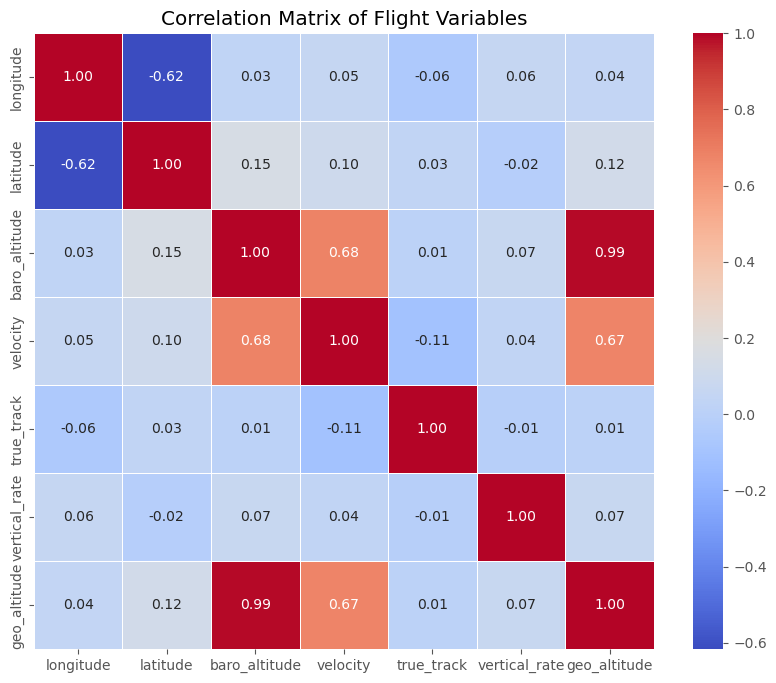

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Flight Variables")

plt.show()

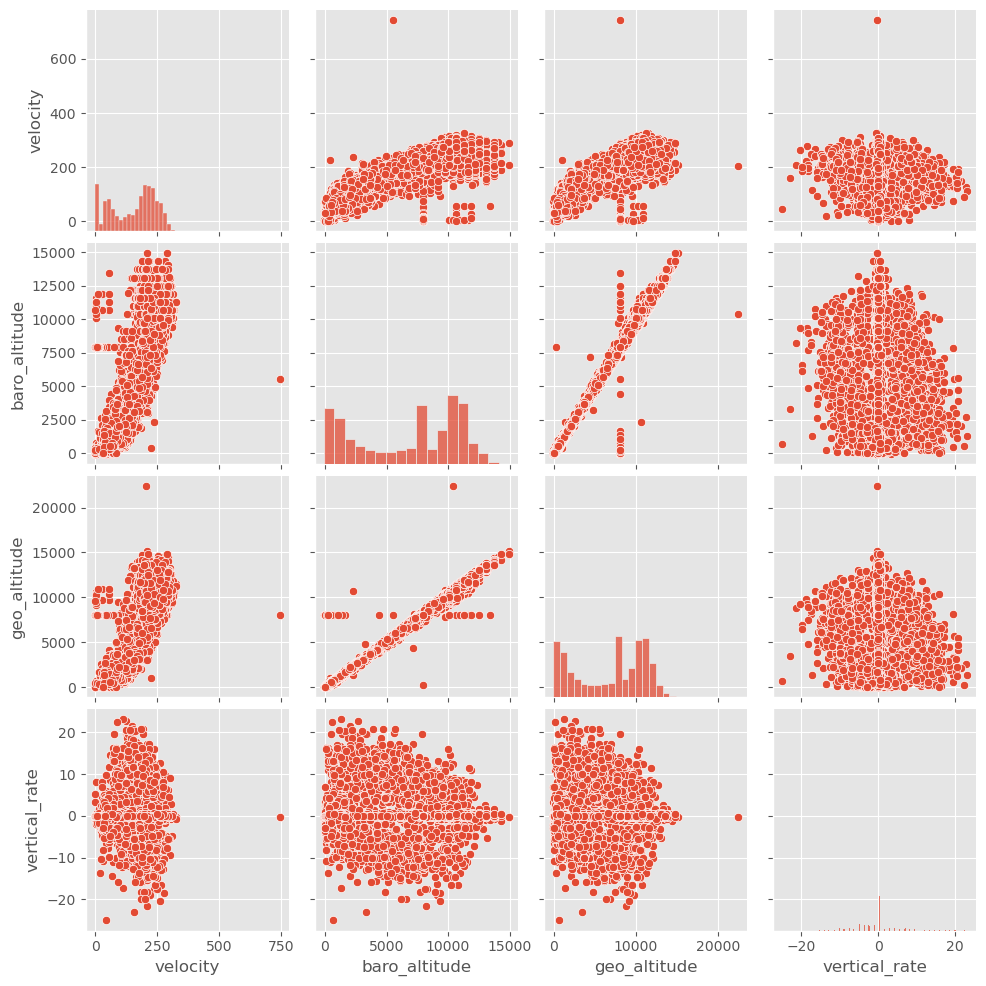

In [ ]:
selected_features = [
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "vertical_rate"
]

sns.pairplot(
    df[selected_features],
    diag_kind="hist"
)

plt.show()

## 6. Geographic Analysis

This section examines the geographical distribution of aircraft positions using latitude and longitude coordinates. Understanding the spatial distribution of aircraft observations provides insights into air traffic concentration, surveillance coverage, and operational flight patterns.

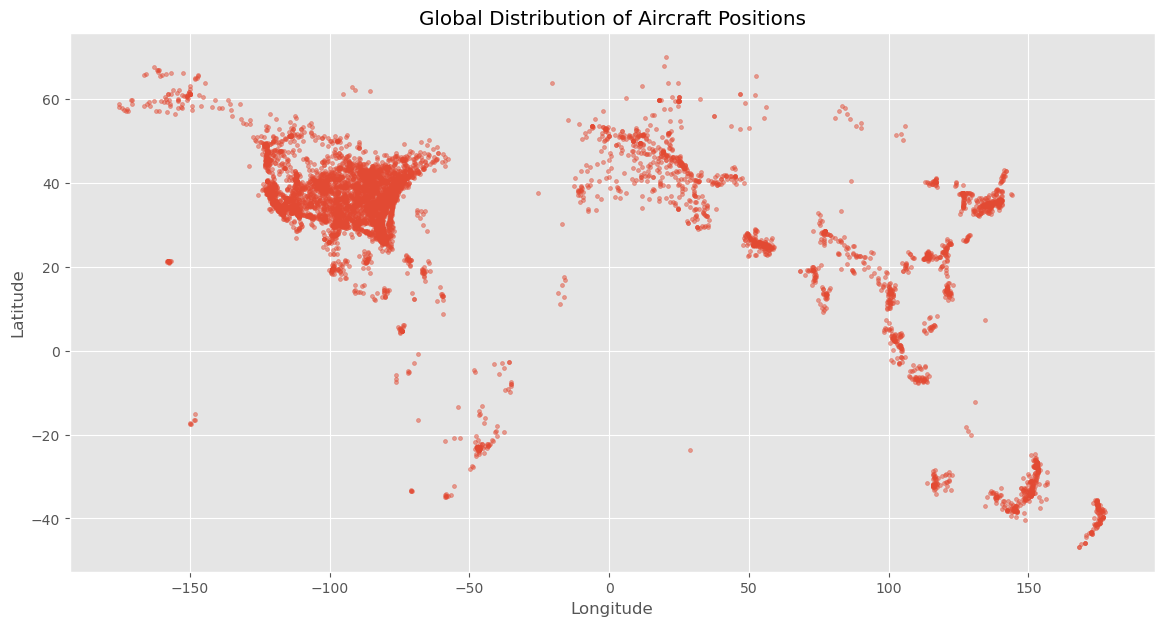

In [ ]:
plt.figure(figsize=(14,7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=8,
    alpha=0.5
)

plt.title("Global Distribution of Aircraft Positions")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.grid(True)

plt.show()

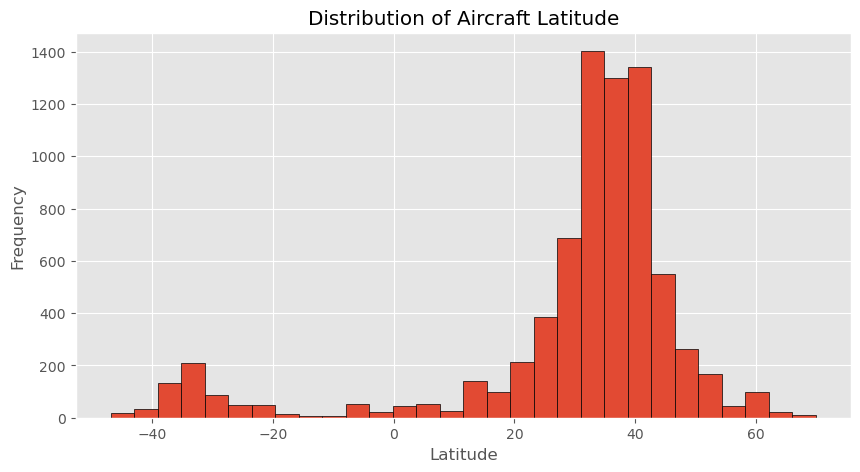

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["latitude"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Aircraft Latitude")

plt.xlabel("Latitude")

plt.ylabel("Frequency")

plt.show()

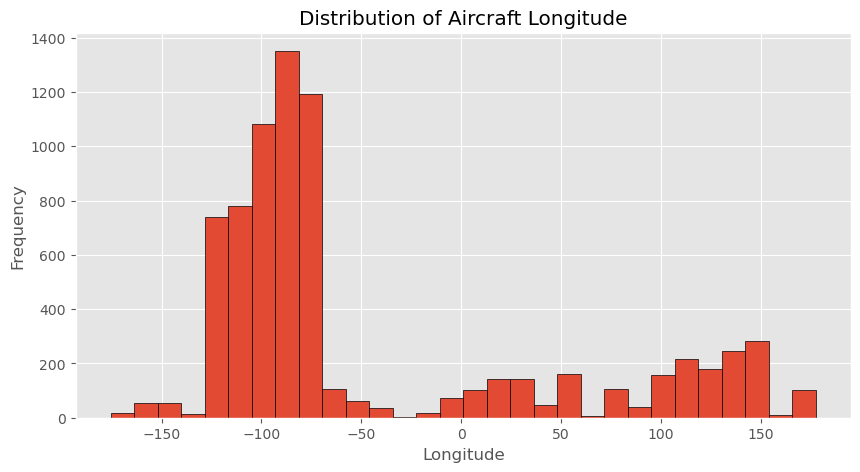

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["longitude"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Aircraft Longitude")

plt.xlabel("Longitude")

plt.ylabel("Frequency")

plt.show()

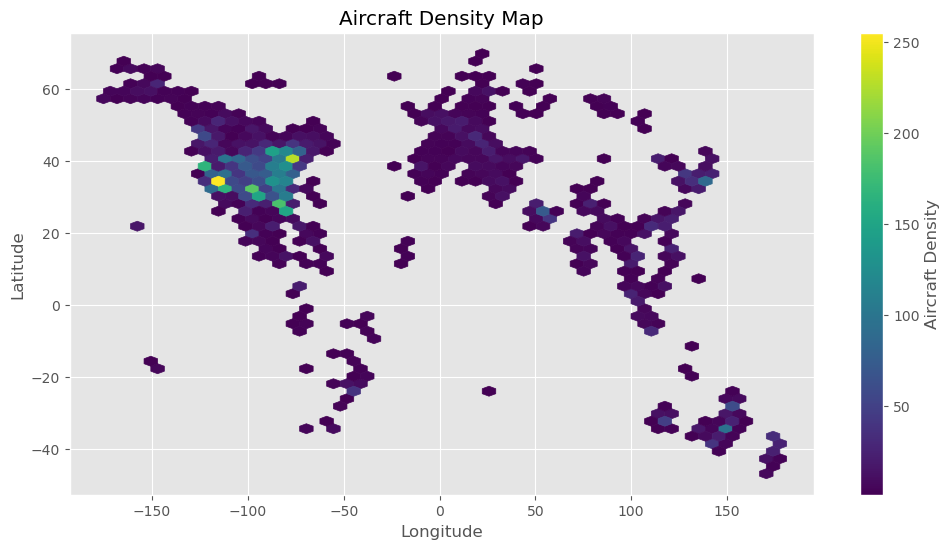

In [ ]:
plt.figure(figsize=(12,6))

plt.hexbin(
    df["longitude"],
    df["latitude"],
    gridsize=50,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Aircraft Density")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Aircraft Density Map")

plt.show()

In [ ]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="callsign",
    hover_data={
        "icao24": True,
        "origin_country": True,
        "velocity": True,
        "baro_altitude": True,
        "geo_altitude": True,
        "true_track": True,
        "vertical_rate": True,
        "latitude": False,
        "longitude": False
    },
    title="Interactive Global Aircraft Positions"
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.7
    )
)

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(240,240,240)",
        showocean=True,
        oceancolor="rgb(210,230,255)",
        showcountries=True,
        projection_type="natural earth"
    ),
    height=700
)

fig.show()

In [ ]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="velocity",
    hover_name="callsign",
    hover_data=[
        "origin_country",
        "baro_altitude",
        "true_track"
    ],
    color_continuous_scale="Turbo",
    title="Aircraft Velocity Distribution"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    geo=dict(
        projection_type="natural earth",
        showcountries=True,
        showland=True
    ),
    height=700
)

fig.show()

In [ ]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="baro_altitude",
    hover_name="callsign",
    hover_data=[
        "velocity",
        "origin_country"
    ],
    color_continuous_scale="Viridis",
    title="Aircraft Altitude Distribution"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    geo=dict(
        projection_type="natural earth",
        showland=True,
        showcountries=True
    ),
    height=700
)

fig.show()

In [ ]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="on_ground",
    hover_name="callsign",
    hover_data=[
        "velocity",
        "origin_country"
    ],
    title="Aircraft Operational Status"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    geo=dict(
        projection_type="natural earth",
        showland=True,
        showcountries=True
    ),
    height=700
)

fig.show()

## 7. Time-Series Analysis

The OpenSky ADS-B dataset records timestamps as Unix epoch values. These timestamps are converted into standard datetime format to analyse the temporal distribution of aircraft observations during the data collection period.

In [ ]:
df["time_position_dt"] = pd.to_datetime(
    df["time_position"],
    unit="s"
)

df["last_contact_dt"] = pd.to_datetime(
    df["last_constant"],
    unit="s"
)

display(
    df[
        [
            "time_position",
            "time_position_dt",
            "last_constant",
            "last_contact_dt"
        ]
    ].head()
)

,time_position,time_position_dt,last_constant,last_contact_dt
0,1.767745e+09,2026-01-07 00:17:28,1767745048,2026-01-07 00:17:28
1,1.767745e+09,2026-01-07 00:17:27,1767745047,2026-01-07 00:17:27
2,1.767745e+09,2026-01-07 00:17:28,1767745048,2026-01-07 00:17:28
3,1.767745e+09,2026-01-07 00:15:17,1767744917,2026-01-07 00:15:17
4,1.767745e+09,2026-01-07 00:17:28,1767745048,2026-01-07 00:17:28


In [ ]:
print("Observation Period")

print("Start Time :", df["time_position_dt"].min())
print("End Time   :", df["time_position_dt"].max())

duration = (
    df["time_position_dt"].max() -
    df["time_position_dt"].min()
)

print("Duration   :", duration)

Observation Period
Start Time : 2026-01-06 22:43:28
End Time   : 2026-01-07 00:17:28
Duration   : 0 days 01:34:00


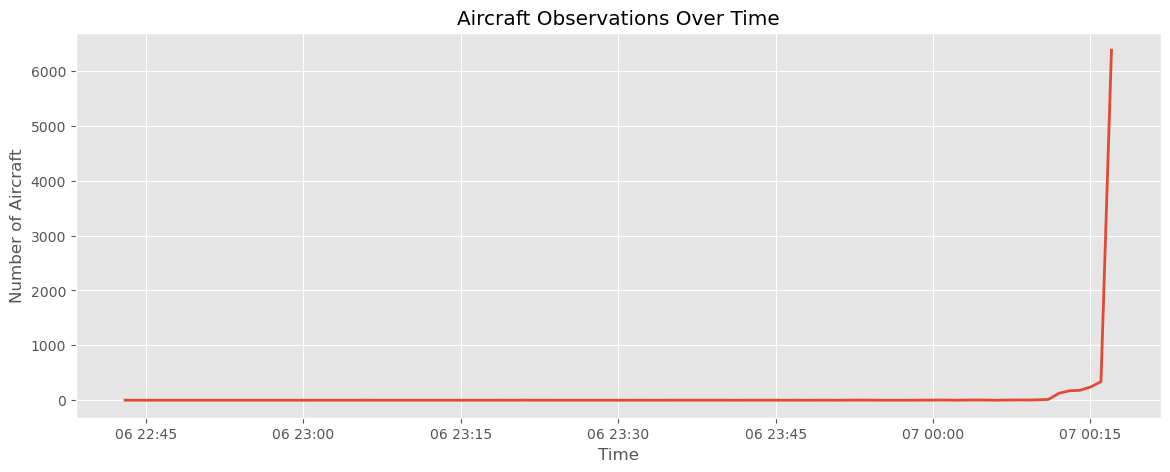

In [ ]:
observations = (
    df
    .set_index("time_position_dt")
    .resample("1min")
    .size()
)

plt.figure(figsize=(14,5))

plt.plot(
    observations.index,
    observations.values,
    linewidth=2
)

plt.title("Aircraft Observations Over Time")

plt.xlabel("Time")

plt.ylabel("Number of Aircraft")

plt.grid(True)

plt.show()

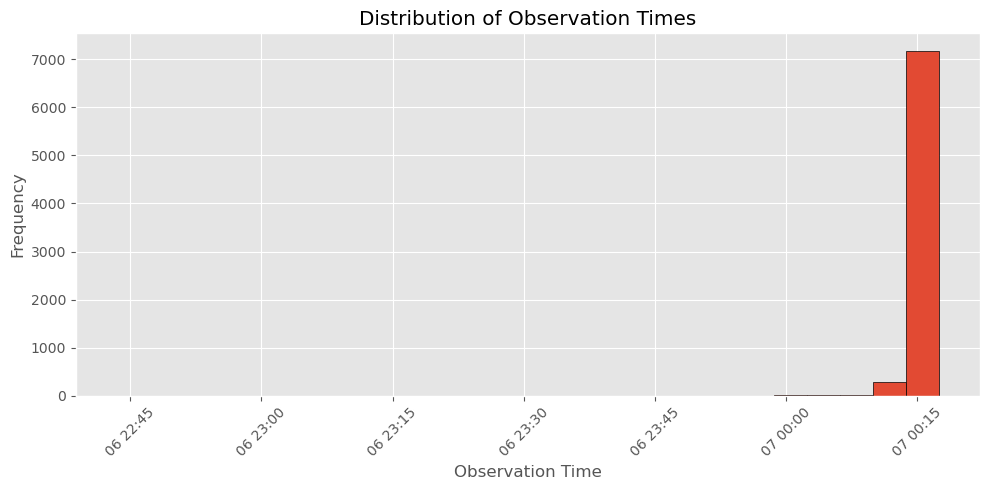

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["time_position_dt"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Observation Times")

plt.xlabel("Observation Time")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
print("Time-Series Summary")


print(f"Total Aircraft Observations : {len(df)}")
print(f"Observation Period          : {duration}")
print(f"Average Observations/Minute : {observations.mean():.2f}")
print(f"Maximum Observations/Minute : {observations.max()}")
print(f"Minimum Observations/Minute : {observations.min()}")

Time-Series Summary
Total Aircraft Observations : 7516
Observation Period          : 0 days 01:34:00
Average Observations/Minute : 79.12
Maximum Observations/Minute : 6378
Minimum Observations/Minute : 0
